In [27]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os 

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import momlevel as ml
import cmocean 

### Load Roemmich and Gilson datasets. These are computed in `ML_RG_Argo_Preprocessing_BAMS2025.ipynb`

In [28]:
os.chdir('/home/tu.temple.edu/tuk08919/BAMS/BAMS_2025')

Temp = xr.open_zarr('Roemmich_Gilson_Temperature_Jan2004_Dec2025.zarr')
Salinity = xr.open_zarr('Roemmich_Gilson_Salinity_Jan2004_Dec2025.zarr')

/tmp/ipykernel_222681/424476593.py:3: RuntimeWarning: Failed to open Zarr store with consolidated metadata, falling back to try reading non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  Temp = xr.open_zarr('Roemmich_Gilson_Temperature_Jan2004_Dec2025.zarr')


GroupNotFoundError: group not found at path ''

### Compute absolute time series of T and S fields, by adding the 2004 to 2018 climatology to the anomaly time series. 

In [ ]:
Temperature_ts = Temp.ARGO_TEMPERATURE_MEAN + Temp.ARGO_TEMPERATURE_ANOMALY
Salinity_ts = Salinity.ARGO_SALINITY_MEAN + Salinity.ARGO_SALINITY_ANOMALY

### Compute global average over the upper 2000 db and check to make sure this matches that here: https://sio-argo.ucsd.edu/RG_Climatology.html

In [ ]:
Mask = Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) / Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) 
Mask = Mask.squeeze()

### Need to depth and area - weight, assume pressure ~ depth here. The functions below are used to compute thickness and grid cell area:

In [ ]:
def calc_bnds(ds, 
              z_center,
              z_top=0):

    # set up empty list to z_bound values to
    z_bounds = [z_top] # assumes surface to be 0

    # loop through Z-centers starting from the first value and up to but excluding the last
    for val in ds[z_center].values[:-1]:

        # each boundary value is equal to the current center value + the current center value mine the last boundary value we appended
        # since we started our z_bound list with 0, the frst loop for CM4/ESM4 would be 2.5 + (2.5-0) = 5.0 m.
        bnd = val + (val-z_bounds[-1])
        
        z_bounds.append(bnd)

    # we handle the special case of the bottom boundary
    # by assuming that the thickness of the bottom cell is equal far from the center of the cell as the top is
    btm_half_thk = (ds[z_center].values[-1] - z_bounds[-1]) 
    btm_zbd = btm_half_thk + ds[z_center].values[-1]

    z_bounds.append(btm_zbd)

    z_bnd_out = np.array(z_bounds)

    # compute cell thickness
    thk = np.diff(z_bounds)

    return xr.DataArray(z_bnd_out,dims='z_bnd', name='pressure'), xr.DataArray(thk,dims='pressure', name='pressure')

import warnings

def standard_grid_cell_area(lat, lon, rE=6371.0e3):
    """ computes the cell area for a standard spherical grid """

    warnings.warn(
        "standard_grid_cell_area is deprecated, use compute_area_regular_grid",
        DeprecationWarning,
    )

    dLat = lat[1] - lat[0]
    dLon = lon[1] - lon[0]
    area = np.empty((len(lat), len(lon)))
    for j in range(0, len(lat)):
        for i in range(0, len(lon)):
            lon1 = lon[i] + dLon / 2
            lon0 = lon[i] - dLon / 2
            lat1 = lat[j] + dLat / 2
            lat0 = lat[j] - dLat / 2
            area[j, i] = (
                (np.pi / 180.0)
                * rE
                * rE
                * np.abs(np.sin(np.radians(lat0)) - np.sin(np.radians(lat1)))
                * np.abs(lon0 - lon1)
            )
    return area

In [ ]:
z_i, thkness = calc_bnds(Temp.pressure,'pressure')
thkness

<xarray.DataArray 'pressure' (pressure: 58)>
array([  5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.,  15.,  20.,  20.,  20.,
        20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  25.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  75., 100., 100., 100.,
       100., 100.,  50.])
Dimensions without coordinates: pressure

In [ ]:
cell_area = standard_grid_cell_area(Temp.coords['latitude'].values, 
                                    Temp.coords['longitude'].values, 
                                    rE=6371.0e3)

areacella_xarray = xr.DataArray(cell_area,dims=(Temp.ARGO_TEMPERATURE_ANOMALY.dims[2],\
                                                Temp.ARGO_TEMPERATURE_ANOMALY.dims[3]),\
                                                coords=(Temp.ARGO_TEMPERATURE_ANOMALY.coords['latitude'],\
                                                        Temp.ARGO_TEMPERATURE_ANOMALY.coords['longitude']))

/tmp/ipykernel_195281/4136764880.py:36: DeprecationWarning: standard_grid_cell_area is deprecated, use compute_area_regular_grid
  warnings.warn(


### Check to make sure map looks reasonable and marginal seas and land are masked out

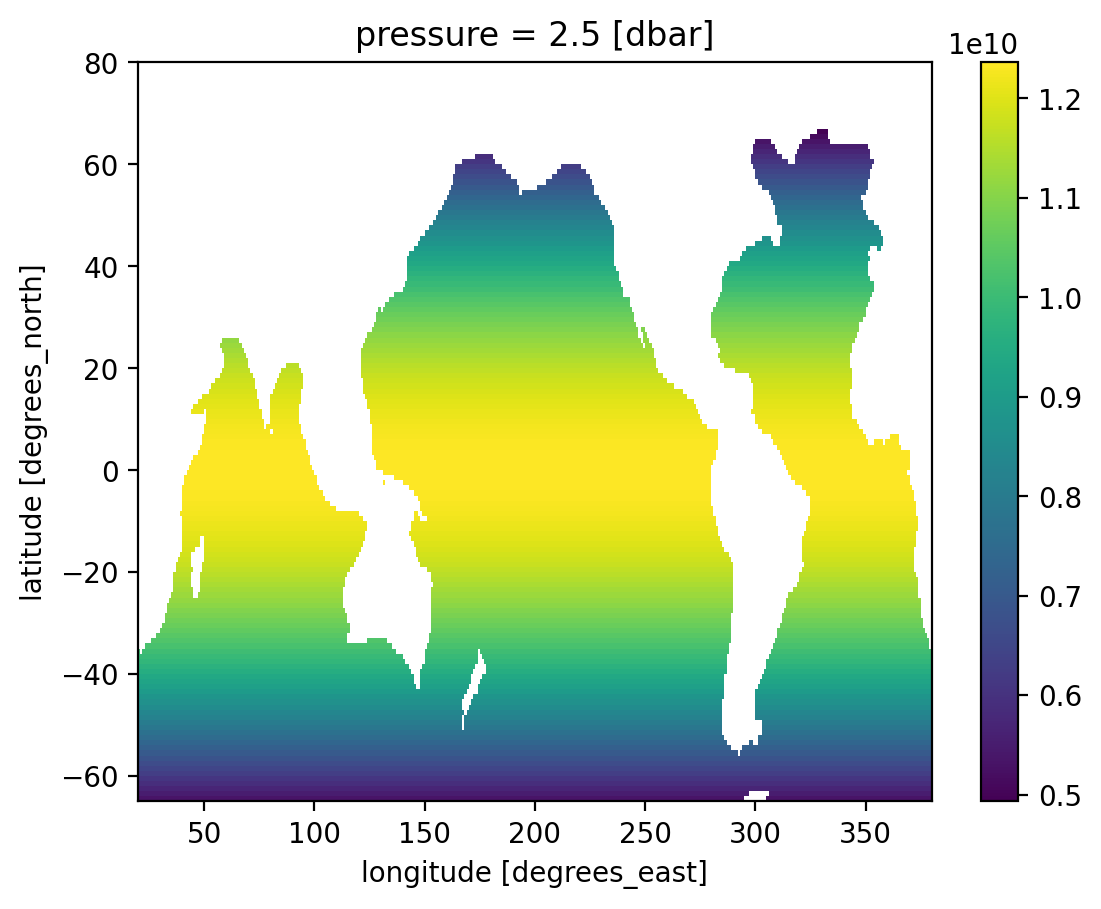

In [ ]:
areamasked = (areacella_xarray*Mask)
areamasked.plot()

### Compute weighted means

In [29]:
## define area and depth weights 
areaweights = areamasked
z_weights = thkness

T_z_weighted = (Temperature_ts*Mask).weighted(z_weights)
T_z = T_z_weighted.mean(dim=['pressure'])

T_z_areaweighted = T_z.weighted(areaweights.fillna(0))
T_global_weighted = T_z_areaweighted.mean(dim=['latitude','longitude'])

### This matches the plot shown at https://sio-argo.ucsd.edu/RG_Climatology.html

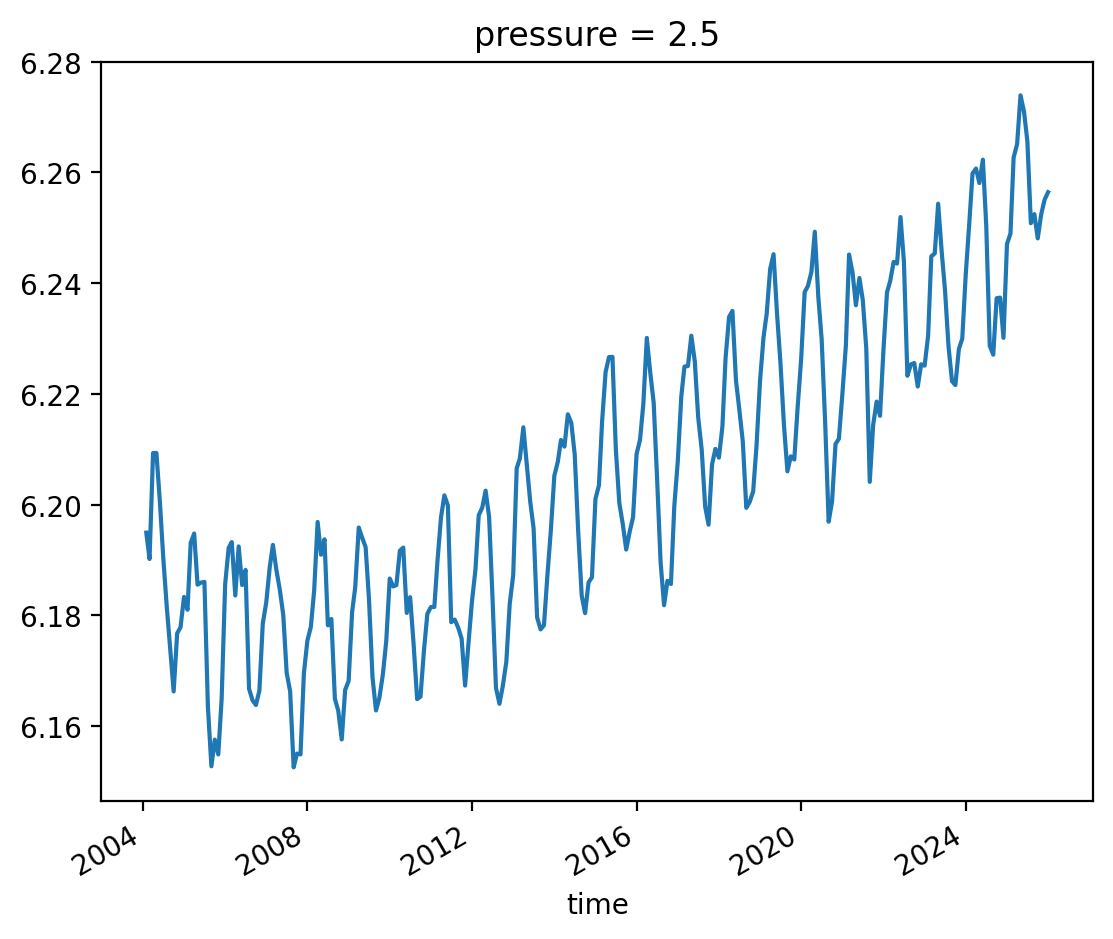

In [30]:
T_global_weighted.plot()

### Compute Potential Density referenced to the surface, which we will use to compute Mixed Layer Depth defined with a 0.03 Kg m-3 criteria. For our potential density calculation we use the momlevel package, employing the Wright EOS and using potential temperature and practical salinity as inputs: https://momlevel.readthedocs.io/en/v0.0.6/api/momlevel.derived.html?highlight=ml.derived#module-momlevel.derived

In [31]:
## Compute potential density referenced to the surface (0)
potential_density_ts = ml.derived.calc_pdens(Temperature_ts, 
                                             Salinity_ts, 
                                             0, 
                                             eos='Wright')

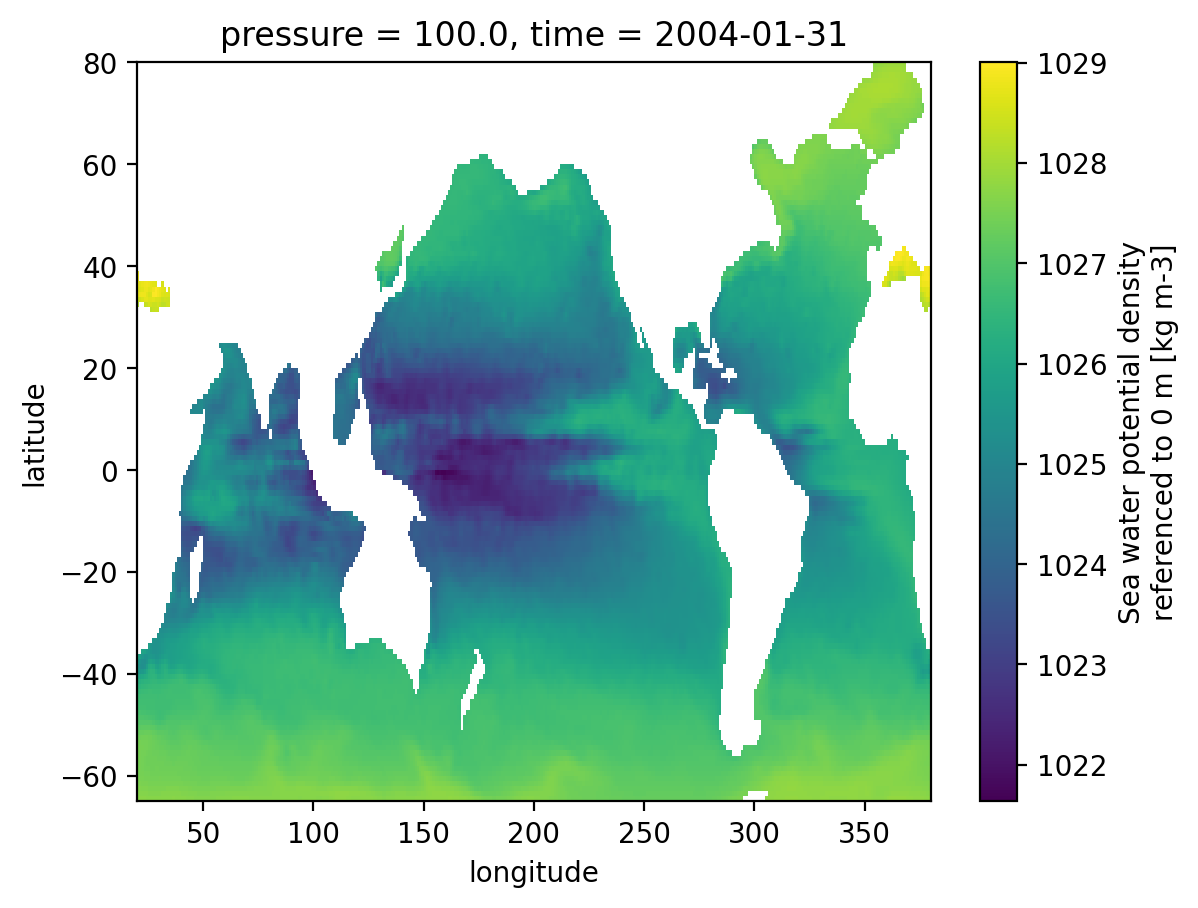

In [32]:
potential_density_ts.isel(time=0,pressure=10).plot()

### Following the de Boyer Montegut et al. (2004) threshold method, MLD is defined as the depth at which potential density changes by the threshold value of 0.03 kg m−3 relative to the 10-m surface reference value. 

##### Here we first compute a time series (for all grid cells) of potential density minus potential density at 10 m (~ 10db), which is index 1 in our dataset (isel(pressure=1)). We then evaluate where this new data array has values LESS THAN 0.03 (<0.03). All the potential density values from the surface to the deepest level where this computed difference is less than 0.03 are retained. These are the values within the mixed layer for every location. We create a "mixed layer mask" where values that are equal to 1 are in the mixed layer and everything else is NaN. (mixed_layer / mixed_layer). We must set index 0 and 1 of this new array to 1 for inclusion the mask, so we do not have 0 / 0.

##### To isolate the temperature, salinity, and potential density values only within the mixed layer we then multiply our T and S fields by our newly created mixed_layer_mask.

In [33]:
## Compute difference relative to 10 m reference value. 10 db ~ 10 m, this is pressure
## index of 1 in this dataset, index 0 is 2.5 db.
drho_relative_to_surface = potential_density_ts - potential_density_ts.isel(pressure=1)
mixed_layer = drho_relative_to_surface.where(drho_relative_to_surface<0.03)
mixed_layer_mask = mixed_layer/mixed_layer
mixed_layer_mask[0] = 1
mixed_layer_mask[1] = 1

## Multiply the property data arrays by the mixed_layer mask created above. This will
Mixed_Layer_T = mixed_layer_mask*Temperature_ts
Mixed_Layer_S = mixed_layer_mask*Salinity_ts
Mixed_Layer_Rho = mixed_layer_mask*potential_density_ts

### Check to make sure this is doing what we want:

In [34]:
Mixed_Layer_T.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values                                                                                                          

array([16.16 , 16.16 , 16.155, 16.149, 16.152, 16.16 , 16.174, 16.012,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan], dtype=float32)

### Create a time series of MLD by finding the deepest pressure value at each grid point (lat,lon,time) in our newly created mixed_layer_mask that is NOT a NaN.

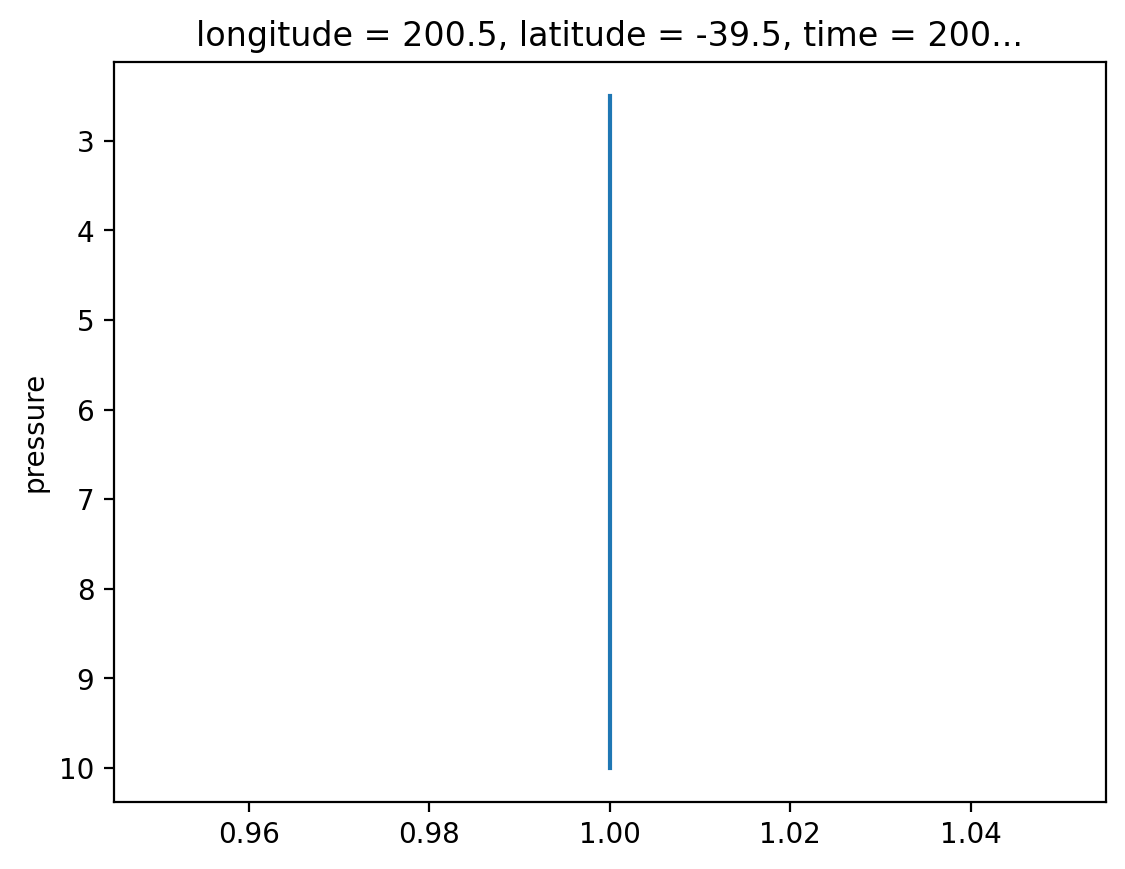

In [35]:
mixed_layer_mask.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',yincrease=False)

In [36]:
pressure_levels_in_mixed_layer = mixed_layer_mask*mixed_layer_mask.pressure
pressure_max_ml = pressure_levels_in_mixed_layer.max(dim='pressure', skipna=True)
mld = pressure_max_ml

### Check to make sure this is doing what we want. Highest pressure returned is equal to the maximum pressure (i.e., depth) where potential density does not exceed 0.03 kg/m3 more than the 10 m potential density for that lat/lon (i.e., local MLD).

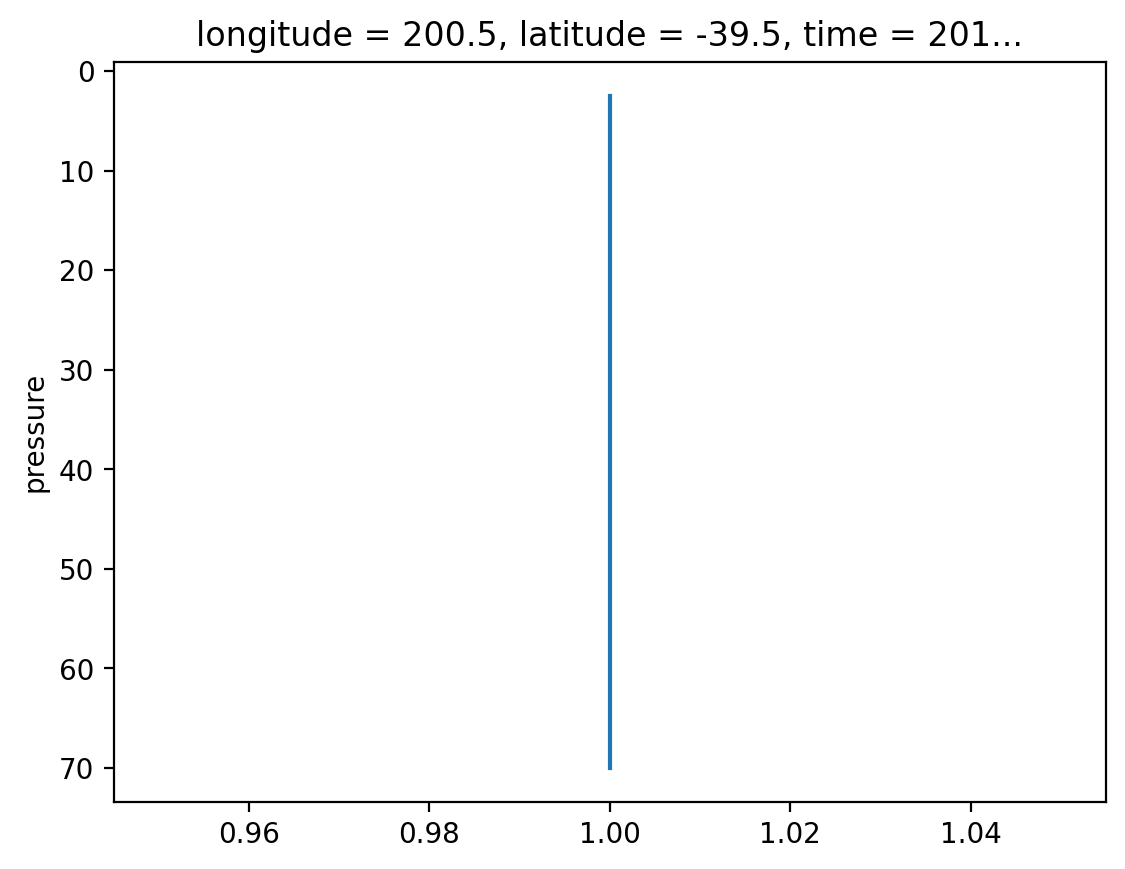

In [37]:
mixed_layer_mask.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',yincrease=False)

### Values match

In [38]:
mld.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values

array(70., dtype=float32)

### Compute depth-averaged (weighted) mixed layer T, S, potential density fields and save out these fields as well as the non-depth averaged fields as netcdf files for the simplicity of future analysis.

In [39]:
z_ml_weights = thkness*mixed_layer_mask  ## create field of thkness that only exists within the mixed layer
MLT_z_weighted = (Mixed_Layer_T).weighted(z_ml_weights.fillna(0))
MLT_z_weighted_ave = MLT_z_weighted.mean(dim='pressure')

MLS_z_weighted = (Mixed_Layer_S).weighted(z_ml_weights.fillna(0))
MLS_z_weighted_ave = MLS_z_weighted.mean(dim='pressure')

MLpotoRho_z_weighted = (Mixed_Layer_Rho).weighted(z_ml_weights.fillna(0))
MLpotoRho_z_weighted_ave = MLpotoRho_z_weighted.mean(dim='pressure')

In [40]:
RG_MixedLayer_Properties = xr.Dataset()

RG_MixedLayer_Properties['MLT_depth_ave'] =  MLT_z_weighted_ave
RG_MixedLayer_Properties['MLS_depth_ave'] =  MLS_z_weighted_ave
RG_MixedLayer_Properties['MLpotoRho_depth_ave'] =  MLpotoRho_z_weighted_ave

RG_MixedLayer_Properties['MLT'] =  Mixed_Layer_T
RG_MixedLayer_Properties['MLS'] =  Mixed_Layer_S
RG_MixedLayer_Properties['MLpotoRho'] =  Mixed_Layer_Rho

RG_MixedLayer_Properties['MLD'] =  mld

In [41]:
RG_MixedLayer_Properties

<xarray.Dataset>
Dimensions:              (longitude: 360, latitude: 145, time: 264, pressure: 58)
Coordinates:
  * longitude            (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude             (latitude) float32 -64.5 -63.5 -62.5 ... 77.5 78.5 79.5
  * time                 (time) datetime64[ns] 2004-01-31 ... 2025-12-31
  * pressure             (pressure) float32 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
Data variables:
    MLT_depth_ave        (latitude, longitude, time) float64 -0.06167 ... nan
    MLS_depth_ave        (latitude, longitude, time) float64 33.76 33.83 ... nan
    MLpotoRho_depth_ave  (latitude, longitude, time) float64 1.027e+03 ... nan
    MLT                  (pressure, latitude, longitude, time) float32 -0.033...
    MLS                  (pressure, latitude, longitude, time) float32 33.75 ...
    MLpotoRho            (pressure, latitude, longitude, time) float32 1.027e...
    MLD                  (latitude, longitude, time) float32 10.0 20.0 ... 10.0

In [42]:
RG_MixedLayer_Properties.to_netcdf('RG_MixedLayer_Properties_2004_to_Jan2004_Dec2025.nc')

In [43]:
RG_MixedLayerProperties = xr.open_dataset('RG_MixedLayer_Properties_2004_to_Jan2004_Dec2025.nc')